# 🏦 **Análise e Classificação de Risco de Crédito**


---

### 🎯 Objetivo
Desenvolver um modelo de Machine Learning capaz de classificar clientes em três categorias de risco de crédito (Ruim, Padrão, Bom), permitindo uma concessão de empréstimos mais segura e automatizada.

### 📊 Principais Resultados
* **Performance:** O modelo final (Random Forest) atingiu **76% de acurácia** e **81% de Recall** na detecção de maus pagadores.
* **Insight de Negócio:** A análise revelou que o **nível de endividamento** é um preditor de risco mais forte do que a **renda anual** do cliente.

## **Imports**

In [ ]:
# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização Gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Configuração para não exibir warnings
import warnings
warnings.filterwarnings('ignore')

## **Base de Dados**

In [ ]:
# Importação da base de dados

pd.set_option('display.max_columns', None)

df = pd.read_csv('train.csv')
df

/tmp/ipython-input-2909763636.py:3: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.0,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.0,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

## **Data Cleaning**

In [ ]:
def clean_numbers(texto):
    if isinstance(texto, str):
        texto = texto.replace('_', '').strip()
        if texto == '':
            return np.nan
    return texto

In [ ]:
cols_to_cleaning = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                       'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
                       'Monthly_Balance']

for col in cols_to_cleaning:
    df[col] = df[col].apply(clean_numbers)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nVerificando tipos de dados após limpeza:")
print(df[cols_to_cleaning].dtypes)


Verificando tipos de dados após limpeza:
Age                          int64
Annual_Income              float64
Num_of_Loan                  int64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
Monthly_Balance            float64
dtype: object


In [ ]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,92998.000000,97909.000000,98035.000000,100000.000000,100000.000000,100000.000000,95521.000000,9.880000e+04
mean,110.649700,1.764157e+05,4194.170850,17.091280,22.47443,72.466040,3.009960,21.068780,30.923342,10.389025,27.754251,1426.220376,32.285173,1403.118217,637.412998,-3.036437e+22
std,686.244717,1.429618e+06,3183.686167,117.404834,129.05741,466.422621,62.647879,14.860104,226.031892,6.789496,193.177339,1155.129026,5.116875,8306.041270,2043.319327,3.181295e+24
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.945750e+04,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.320000,3.000000,566.072500,28.052567,30.306660,74.534002,2.700922e+02
50%,33.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.155000,32.305784,69.249473,135.925682,3.367192e+02
75%,42.000000,7.279092e+04,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.870000,9.000000,1945.962500,36.496663,161.224249,265.731733,4.702202e+02
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,4998.070000,50.000000,82331.000000,10000.000000,1.602041e+03


**Tratamento de Outliers e Dados Inconsistentes:** A análise exploratória identificou valores fisicamente impossíveis (ex: Idade > 500, número negativo de contas bancárias). Aplicaram-se filtros baseados em regras de negócio para garantir a integridade da modelagem.

In [ ]:
# Limpeza de dados númericos

df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
df = df[(df['Num_Bank_Accounts'] >= 0) & (df['Num_Bank_Accounts'] <= 20)]
df = df[(df['Num_Credit_Card'] >= 0) & (df['Num_Credit_Card'] <= 20)]
df = df[(df['Interest_Rate'] >= 0) & (df['Interest_Rate'] <= 100)]
df = df[(df['Num_of_Loan'] >= 0) & (df['Num_of_Loan'] <= 20)]
df = df[(df['Delay_from_due_date'] >= 0)]
df = df[df['Monthly_Balance'] > -1000000]
df = df[(df['Num_of_Delayed_Payment'] >= 0) & (df['Num_of_Delayed_Payment'] <= 100)]
df = df[(df['Num_Credit_Inquiries'] >= 0) & (df['Num_Credit_Inquiries'] <= 100)]

print("Estatísticas após a limpeza:")
display(df.describe())

Estatísticas após a limpeza:


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,76258.000000,7.625800e+04,64779.000000,76258.000000,76258.000000,76258.000000,76258.000000,76258.000000,76258.000000,74649.000000,76258.000000,76258.000000,76258.000000,76258.000000,72860.000000,76258.000000
mean,33.244132,1.749767e+05,4141.446127,5.404521,5.552021,14.645611,3.537216,21.281256,13.451507,10.453967,5.846364,1432.483343,32.322659,1417.576419,623.881513,401.180641
std,10.778088,1.427911e+06,3155.987173,2.574393,2.061622,8.811477,2.444326,14.791836,6.211781,6.797535,4.050224,1155.831555,5.113702,8345.468165,2031.555099,212.755957
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.480000,0.000000,0.230000,20.881250,0.000000,0.000000,0.088628
25%,24.000000,1.927195e+04,1616.951250,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.380000,3.000000,569.380000,28.096692,30.208315,73.518201,269.733761
50%,33.000000,3.688606e+04,3049.616667,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.470000,6.000000,1171.730000,32.341532,68.311538,133.282360,335.987817
75%,42.000000,7.183000e+04,5893.630000,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,15.020000,9.000000,1961.870000,36.544387,156.055359,256.254334,468.241965
max,99.000000,2.419806e+07,15204.633333,11.000000,20.000000,100.000000,19.000000,67.000000,94.000000,36.490000,93.000000,4998.070000,50.000000,82331.000000,10000.000000,1602.040519


In [ ]:
# Limpeza de dados textuais

def month_convert(text):
    if pd.isnull(text):
        return np.nan

    text = str(text)

    try:
        years = int(text.split('Year')[0].strip())
        months = int(text.split('and')[1].split('Month')[0].strip())
        total_months = (years * 12) + months
        return total_months
    except:
        return np.nan

df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(month_convert)

print("Exemplo da conversão:")
display(df[['Credit_History_Age', 'Credit_History_Age_Months']].head())

print("\nValores nulos resultantes:")
print(df['Credit_History_Age_Months'].isnull().sum())

df = df.drop(columns=['Credit_History_Age'])

Exemplo da conversão:


,Credit_History_Age,Credit_History_Age_Months
0,22 Years and 1 Months,265.0
3,22 Years and 4 Months,268.0
5,22 Years and 6 Months,270.0
6,22 Years and 7 Months,271.0
7,NaN,NaN



Valores nulos resultantes:
6901


In [ ]:
# Substituindo

map_credit_mix = {'Bad': 0, 'Standard': 1, 'Good': 2}
map_credit_score = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(map_credit_mix)
df['Credit_Score'] = df['Credit_Score'].map(map_credit_score)


cols_to_one_hot = ['Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']
df = pd.get_dummies(df, columns=cols_to_one_hot, drop_first=True)


cols_to_remove = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan']
df = df.drop(columns=[c for c in cols_to_remove if c in df.columns], errors='ignore')

df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Age_Months,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Occupation________,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,23,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,NaN,809.98,26.822620,49.574949,80.415295,312.494089,2,265.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False
3,23,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,2.0,809.98,31.377862,49.574949,199.458074,223.451310,2,268.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True
5,23,19114.12,NaN,3,4,3,4,8,4.0,9.27,4.0,2.0,809.98,27.262259,49.574949,62.430172,340.479212,2,270.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
6,23,19114.12,1824.843333,3,4,3,4,3,8.0,11.27,4.0,2.0,809.98,22.537593,49.574949,178.344067,244.565317,2,271.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True
7,23,19114.12,1824.843333,3,4,3,4,3,6.0,11.27,4.0,2.0,809.98,23.933795,49.574949,24.785217,358.124168,1,NaN,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False


In [ ]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

display(df.head())

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Age_Months,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Occupation________,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,23,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,NaN,809.98,26.822620,49.574949,80.415295,312.494089,2,265.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0
3,23,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,2.0,809.98,31.377862,49.574949,199.458074,223.451310,2,268.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
5,23,19114.12,NaN,3,4,3,4,8,4.0,9.27,4.0,2.0,809.98,27.262259,49.574949,62.430172,340.479212,2,270.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
6,23,19114.12,1824.843333,3,4,3,4,3,8.0,11.27,4.0,2.0,809.98,22.537593,49.574949,178.344067,244.565317,2,271.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
7,23,19114.12,1824.843333,3,4,3,4,3,6.0,11.27,4.0,2.0,809.98,23.933795,49.574949,24.785217,358.124168,1,NaN,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0


In [ ]:
# Verificação de dados nulos

nulls = df.isnull().sum()
nulls_percent = (df.isnull().sum() / len(df)) * 100

print(nulls_percent[nulls_percent > 0].sort_values(ascending=False))

Credit_Mix                   20.290330
Monthly_Inhand_Salary        15.052847
Credit_History_Age_Months     9.049542
Amount_invested_monthly       4.455926
Changed_Credit_Limit          2.109943
dtype: float64


In [ ]:
# Imputando

mode_credit_mix = df['Credit_Mix'].mode()[0]
df['Credit_Mix'] = df['Credit_Mix'].fillna(mode_credit_mix)

null_number_cols = [
    'Monthly_Inhand_Salary',
    'Credit_History_Age_Months',
    'Amount_invested_monthly',
    'Changed_Credit_Limit'
]

for col in null_number_cols:
    if col in df.columns:
        median = df[col].median()
        df[col] = df[col].fillna(median)


if 'Credit_History_Age' in df.columns:
    df['Credit_History_Age'] = df['Credit_History_Age'].fillna(df['Credit_History_Age'].mode()[0])


nulls = df.isnull().sum().sum()
print(f"Total de nulos na base: {nulls}")

Total de nulos na base: 0


## **Análise Exploratória**

/tmp/ipython-input-1400982558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Credit_Score', data=df, palette='viridis', order=['0', '1', '2'])


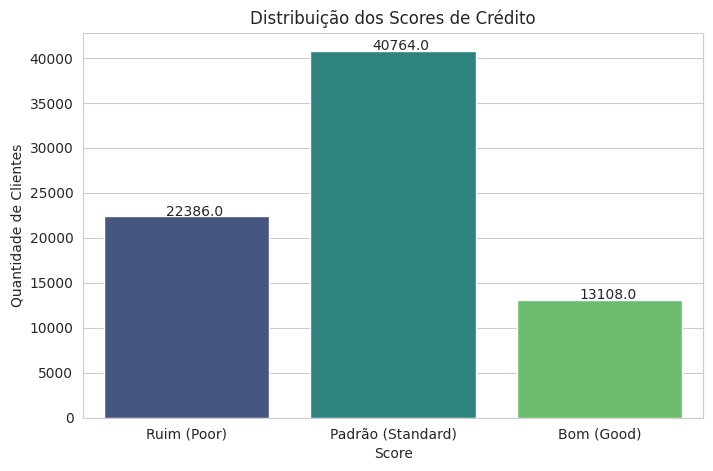

In [ ]:
# Distribuição dos Scores de Crédito

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.countplot(x='Credit_Score', data=df, palette='viridis', order=['0', '1', '2'])
plt.xticks([0, 1, 2], ['Ruim (Poor)', 'Padrão (Standard)', 'Bom (Good)'])
plt.title('Distribuição dos Scores de Crédito')
plt.xlabel('Score')
plt.ylabel('Quantidade de Clientes')


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 100))

plt.show()

In [ ]:
# Balanceamento

min_size = df['Credit_Score'].value_counts().min()
print(f"Tamanho da menor classe: {min_size}")

df_poor = df[df['Credit_Score'] == 0]
df_standard = df[df['Credit_Score'] == 1]
df_good = df[df['Credit_Score'] == 2]

df_poor_bal = df_poor.sample(n=min_size, random_state=42)
df_standard_bal= df_standard.sample(n=min_size, random_state=42)
df_good_bal = df_good.sample(n=min_size, random_state=42)

df_balanced = pd.concat([df_poor_bal, df_standard_bal, df_good_bal])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nNovo tamanho da base: {df_balanced.shape}")
print("\nNova distribuição das classes:")
print(df_balanced['Credit_Score'].value_counts())

Tamanho da menor classe: 13108

Novo tamanho da base: (39324, 42)

Nova distribuição das classes:
Credit_Score
1    13108
2    13108
0    13108
Name: count, dtype: int64


**Análise:**

Ao analisar a distribuição da variável alvo (`Credit_Score`), identificou-se um desequilíbrio significativo entre as classes:

* **Standard:** ~40.700 amostras
* **Poor:** ~22.300 amostras
* **Good:** ~13.100 amostras

Modelos de Machine Learning tendem a ser enviesados pela classe majoritária. Neste cenário, um modelo "preguiçoso" poderia prever "Standard" para todos os clientes e ainda assim obter uma acurácia artificialmente alta, mas falharia em identificar os bons pagadores, que são justamente o público-alvo para concessão de crédito.

Para garantir que o modelo aprenda as características de cada perfil de forma igualitária, optou-se pela técnica de Undersampling (Subamostragem). Reduzimos aleatoriamente as classes 'Standard' e 'Poor' para o mesmo tamanho da classe minoritária ('Good' ≈ 13.000), totalizando uma base de treino balanceada e justa para a comparação entre algoritmos.

/tmp/ipython-input-72351887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, palette='coolwarm', order=[0, 1, 2])


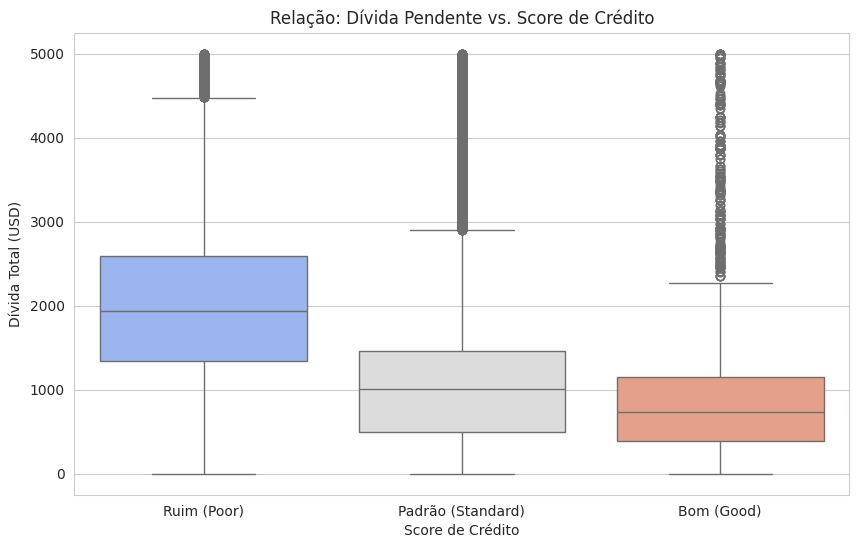

In [ ]:
# Boxplot - Dívida Pendente vs. Score de Crédito

plt.figure(figsize=(10, 6))

sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, palette='coolwarm', order=[0, 1, 2])
plt.xticks([0, 1, 2], ['Ruim (Poor)', 'Padrão (Standard)', 'Bom (Good)'])
plt.title('Relação: Dívida Pendente vs. Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Dívida Total (USD)')
plt.show()

**Análise:**

Este boxplot valida a hipótese de que o endividamento é um forte preditor de risco. Vemos claramente que clientes 'Ruins' (Azul) concentram-se em faixas de dívida muito maiores (mediana ~$2k) do que os 'Bons' (Laranja). Porém, a presença de outliers na categoria 'Bom' (pontos altos no gráfico laranja) mostra que a dívida sozinha não define o score, reforçando a necessidade de um modelo multivariado como o Random Forest para capturar o contexto completo do cliente.

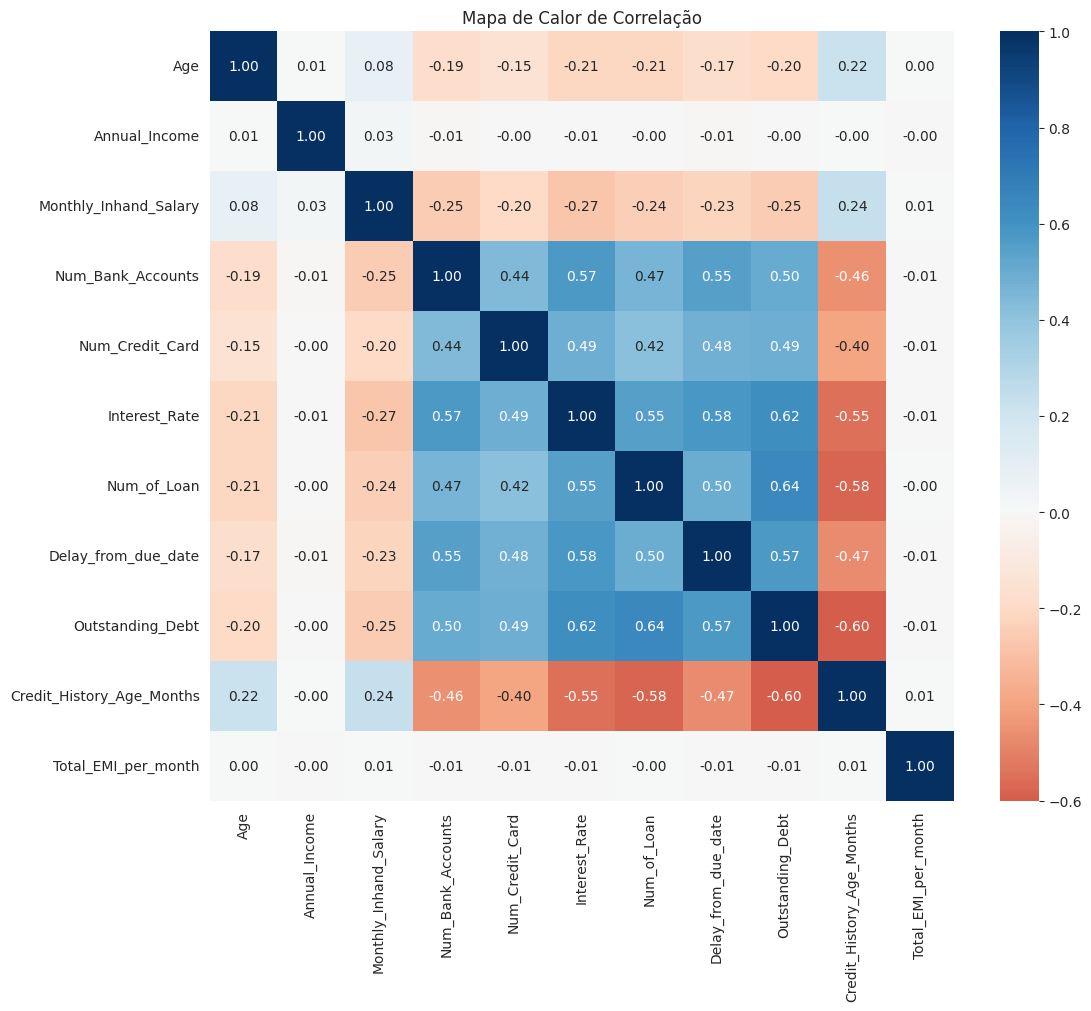

In [ ]:
# Matriz de Correlação

number_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary',
                  'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                  'Num_of_Loan', 'Delay_from_due_date', 'Outstanding_Debt',
                  'Credit_History_Age_Months', 'Total_EMI_per_month']

plt.figure(figsize=(12, 10))
sns.heatmap(df[number_cols].corr(), annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Mapa de Calor de Correlação')
plt.show()

**Análise:**

A matriz de correlação foi gerada para identificar possíveis redundâncias entre as variáveis preditoras (multicolinearidade), que poderiam prejudicar a performance do modelo.

O maior coeficiente de correlação encontrado foi de 0.64 (entre `Num_of_Loan` e `Outstanding_Debt`). Como este valor está abaixo dos limites de corte usuais (0.80 ou 0.90), conclui-se que as variáveis trazem informações independentes e complementares para o modelo.

Portanto, nenhuma variável precisou ser excluída nesta etapa, preservando o máximo de informação para o treinamento.

## **Modelos**

In [ ]:
X = df_balanced.drop(columns=['Credit_Score'])
y = df_balanced['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Regressão Logística Multinomial
print("\nModelo 1: Regressão Logística Multinomial")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia Regressão Logística Multinomial: {acc_log:.2%}")


# Random Forest
print("\nModelo 2: Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia Random Forest: {acc_rf:.2%}")



print("\nRESULTADOS")
results = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia': [acc_log, acc_rf]
})
display(results)


Modelo 1: Regressão Logística
Acurácia Regressão Logística: 67.40%

Modelo 2: Random Forest
Acurácia Random Forest: 76.26%

RESULTADOS


,Modelo,Acurácia
0,Regressão Logística,0.673999
1,Random Forest,0.762619


--- Iniciando Avaliação Profunda ---
--- Relatório Detalhado: Regressão Logística ---
              precision    recall  f1-score   support

        Ruim       0.72      0.68      0.70      2616
      Padrão       0.63      0.54      0.58      2659
         Bom       0.67      0.80      0.73      2590

    accuracy                           0.67      7865
   macro avg       0.67      0.68      0.67      7865
weighted avg       0.67      0.67      0.67      7865

--- Relatório Detalhado: Random Forest ---
              precision    recall  f1-score   support

        Ruim       0.79      0.81      0.80      2616
      Padrão       0.74      0.62      0.68      2659
         Bom       0.75      0.85      0.80      2590

    accuracy                           0.76      7865
   macro avg       0.76      0.76      0.76      7865
weighted avg       0.76      0.76      0.76      7865


=== PLACAR FINAL (Métricas Ponderadas) ===


,Modelo,Acurácia,F1-Score,Recall,Precisão
0,Regressão Logística,0.673999,0.670393,0.673999,0.673387
1,Random Forest,0.762619,0.759301,0.762619,0.761483


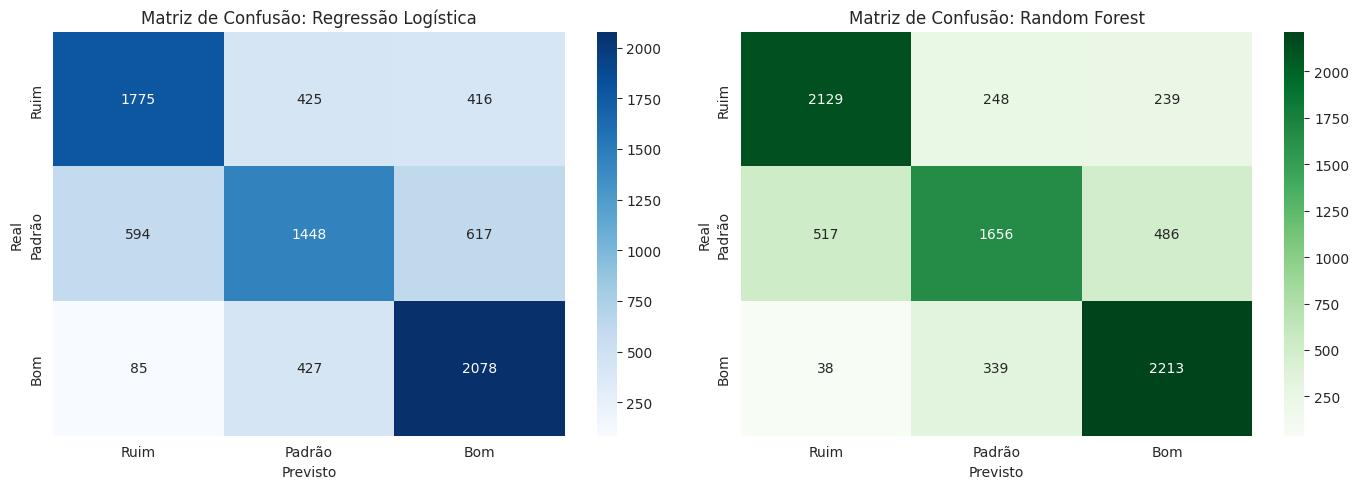

In [ ]:
# Função auxiliar para não repetir código
def avaliar_modelo(modelo, X_test, y_test, nome_modelo):
    y_pred = modelo.predict(X_test)

    # 1. Calculando as métricas isoladas (usamos 'weighted' para média ponderada das 3 classes)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')

    print(f"--- Relatório Detalhado: {nome_modelo} ---")
    print(classification_report(y_test, y_pred, target_names=['Ruim', 'Padrão', 'Bom']))

    return y_pred, {'Modelo': nome_modelo, 'Acurácia': acc, 'F1-Score': f1, 'Recall': recall, 'Precisão': precision}

print("--- Iniciando Avaliação Profunda ---")

# 1. Avaliando Regressão Logística
y_pred_log, metricas_log = avaliar_modelo(log_reg, X_test_scaled, y_test, "Regressão Logística")

# 2. Avaliando Random Forest
y_pred_rf, metricas_rf = avaliar_modelo(rf_model, X_test_scaled, y_test, "Random Forest")

# 3. Tabela Comparativa Final
df_resultados = pd.DataFrame([metricas_log, metricas_rf])
print("\n=== PLACAR FINAL (Métricas Ponderadas) ===")
display(df_resultados.style.highlight_max(color='lightgreen', axis=0))

# 4. Plotando as Matrizes de Confusão Lado a Lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Logística
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Regressão Logística')
ax[0].set_xlabel('Previsto')
ax[0].set_ylabel('Real')
ax[0].set_xticklabels(['Ruim', 'Padrão', 'Bom'])
ax[0].set_yticklabels(['Ruim', 'Padrão', 'Bom'])

# Matriz Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz de Confusão: Random Forest')
ax[1].set_xlabel('Previsto')
ax[1].set_ylabel('Real')
ax[1].set_xticklabels(['Ruim', 'Padrão', 'Bom'])
ax[1].set_yticklabels(['Ruim', 'Padrão', 'Bom'])

plt.tight_layout()
plt.show()

**Análise:**

A comparação entre os modelos na base de teste balanceada revelou a superioridade da Random Forest, que atingiu 76% de acurácia contra 67% da Regressão Logística. Mais importante que a acurácia global foi o ganho em Recall na classe 'Ruim' (0.81 vs 0.68), indicando que o modelo de árvore é significativamente mais eficaz na detecção de risco de inadimplência, reduzindo a exposição financeira da instituição.

/tmp/ipython-input-2540496734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=feature_importances, palette='viridis')


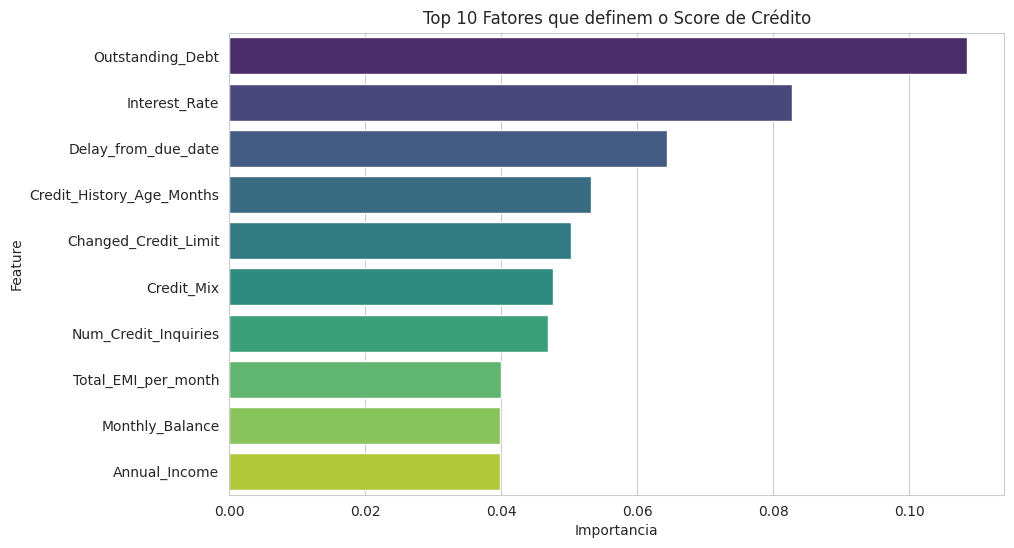

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=feature_importances, palette='viridis')
plt.title('Top 10 Fatores que definem o Score de Crédito')
plt.show()

**Interpretando o Modelo: O que define um bom Score?**


Ao analisarmos a importância das variáveis (Feature Importance) gerada pelo Random Forest, conseguimos compreender quais fatores o algoritmo priorizou para classificar os clientes. O gráfico revela uma hierarquia clara de decisão, onde o nível de endividamento e o comportamento de pagamento superam largamente a capacidade de renda bruta.

A variável Outstanding_Debt (Dívida Pendente) destaca-se isoladamente como o fator mais determinante para o score. Isso indica que, para o modelo, o montante total que o cliente deve é o indicador de risco mais crítico, superando qualquer outra característica. Em seguida, vemos fatores comportamentais fortes como Interest_Rate e Delay_from_due_date. A alta relevância da taxa de juros sugere que o modelo detectou que clientes classificados como "risco" (que pagam taxas maiores) tendem a manter esse perfil, enquanto os dias de atraso confirmam a pontualidade como um pilar central da avaliação de crédito.

Um insight de negócio valioso que esta análise traz é a posição da Annual_Income (Renda Anual), que aparece apenas no final do ranking das 10 mais importantes. Isso quebra o senso comum de que "ganhar bem garante crédito". O modelo aprendeu matematicamente que a estabilidade financeira (representada pela idade do histórico de crédito e dívida controlada) e a disciplina de pagamento são preditores muito mais confiáveis de um bom pagador do que apenas o salário mensal. Na prática, isso valida a estratégia do banco de focar a análise na saúde financeira atual do cliente, e não apenas em seus rendimentos.